# Continuous Hopfield Network

## ¿Qué es?
Una red de Hopfield es un tipo de red neuronal recurrrente diseñada para almacenar y recuperar patrones al imitar la memoria asociativa del cerebro humano.

Esta red actualiza iterativamente las neuronas interconectadas hasta que el sistema converge en la estabilidad, lo que representa un patron almacenado. Esto es especialmente bueno para recuperar información completa de entras parciales o ruidosas.

El modelo de Hopfield actúa como un modelo auto - asociativo ya que asocia un patrón consigo mismo

### Descripción general
- Consiste en una capa de neuronas, cada una conectada con todas las demás. En otras palabras, consiste en un conjunto de neuronas y un conjunto de unidades de retraso temporal, formando un sistema de retro alimentación con múltiples bucles.
- Su convergencia es grarantizada a un mínimo local, pero no necesariamente a uno de los patrones alamacenados.

<img src="IMG/hopfield_nn_diagram.png" width="50%"/>


Donde:
- p = valor de entrada
- w = peso sináptico
- n = net input
- b = bias
- S = función de transferencias (satlins)
- D = Delay Block

Este modelo se inicializa con $a(t = 0) = p$, y su comportamiento esta dada por:
$$
a(t + 1) = satlins(Wa(t) + b)
$$

O en su otra forma,

$$
x_i(t + 1) = f(\sum_{j} w_{ij} x_{j}(t) - \theta_{i})
$$

Cuando las neuronas hacen  uso de los valores ${1,-1}$, entonces $f(x) = satlins(x)$.

<img src="IMG/satlins_definition.png" width="50%"/>

En este caso, el estado $+1$ indica una neurona activada, el $-1$ que desactivada.

En general, ante las entradas: $x_{i}(t)$ la red proporciona las salidas: $y_{i}(t)$, que se convierten en las nuevas entradas: $x_{i}(t + 1)$


## Construcción de Memoria ($M_{ij}$)

### Etapa 1: Para cada asociación se encuentra la matriz

$$
x^{k}(x^{k})^{T}  = 
\begin{pmatrix}
x_{1}^{k} \\
\vdots \\
x_{n}^{k}
\end{pmatrix}
\begin{pmatrix}
x_{1}^{k} & \cdots & x_{n}^{k}
\end{pmatrix}
=
\begin{pmatrix}
x_{1}^{k}x_{1}^{k} & \cdots & x_{1}^{k}x_{n}^{k} \\
\vdots & \ddots & \vdots \\
x_{n}^{k}x_{1}^{k} & \cdots & x_{n}^{k}x_{n}^{k}
\end{pmatrix}
$$

### Etapa 2: A cada matriz se le resta la matriz Identidad

$$
x^{k}(x^{k})^{T} - I = 

\begin{pmatrix}
0 & \cdots & x_{1}^{k}x_{n}^{k} \\
\vdots & \ddots & \vdots \\
x_{n}^{k}x_{1}^{k} & \cdots & 0
\end{pmatrix}
$$

### Etapa 3: Se suman las $p$ matrices

$$
M = \sum_{k = 1}^{p} [x^{k}(x^{k})^{T} - I] = [m_{ij}]_{nxn}
$$

## Fase de Recuperación

### Etapa 1: Inicialización
Sea $t = 0, x(t) = v$, donde $v$ es la entrada (patron) como vector columna de tamaño $(n*m)$ x 1

### Etapa 2: Ciclo de calculo

```python
1. Mientras x(t + 1) no sea igual que x(t):
2. |    aux = Memoria * x(t)
3. |    Para cada elemento en aux:
4. |    |    Si el elemento actual es menor que 0,
5. |    |    |    x(t + 1) = -1
6. |    |    en otro caso,
7. |    |    |    x(t + 1) = 1
8. |    |
9. |    x(t) = x(t + 1)
```

### Etapa 3: Transformación
Al terminar el paso anterior, el patron convergera en alguno de los patrones y se almacenara en $x(t)$ pero, el resultado tendrá el tamaño de $(n*m)$ x 1 , se tendrá que convertir el vector columna resultante en las dimensiones correspondientes, es decir $n$ x $m$.


# Ejemplo de implementación

## Paso 1: Definición de patrones
Se definen los siguiente patrones para A , E, I, O y U de la siguiente forma.

<img src="IMG/patterns_example_hopfield.png" width="50%"/>




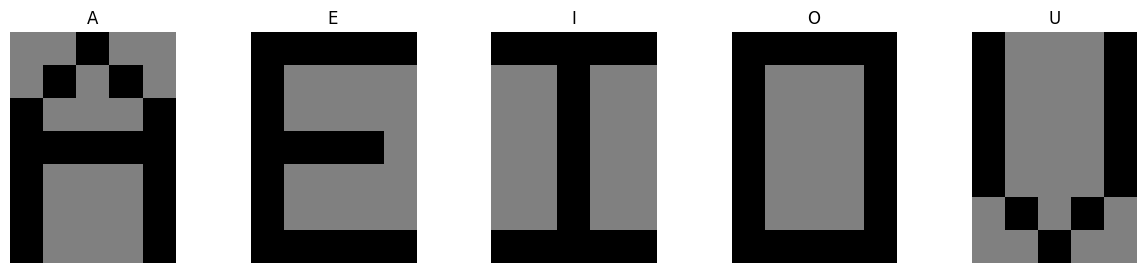

In [56]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import random


#.--------------------------
#  Visualizaicón gráfica de patrones
#.--------------------------

def plot_matrix(matrix, title=""):
    # Definir colores: -1, 0, 1
    cmap = ListedColormap(['gray', 'white', 'black'])
    
    # Normalizar valores a índices: -1→0, 0→1, 1→2
    normalized = matrix + 1
    
    plt.imshow(normalized, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def plot_matrices(matrices, titles=None):
    n = len(matrices)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    
    cmap = ListedColormap(['gray', 'white', 'black'])
    
    for i, matrix in enumerate(matrices):
        normalized = matrix + 1  # -1→0, 0→1, 1→2
        
        axes[i].imshow(normalized, cmap=cmap)
        axes[i].axis('off')
        
        if titles:
            axes[i].set_title(titles[i])
    
    plt.show()


#.--------------------------
#  PATRONES
#.--------------------------

container_A = [
    [0, 0, 1, 0, 0],
    [0, 1, 0, 1, 0],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1]
]

container_E = [
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 1, 1, 1, 1]
]

container_I = [
    [1, 1, 1, 1, 1],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1]
]

container_O = [
    [1, 1, 1, 1, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 1, 1, 1, 1]
]

container_U = [
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [1, 0, 0, 0, 1],
    [0, 1, 0, 1, 0],
    [0, 0, 1, 0, 0]
]

#.--------------------------
#  Cambio de 0's a -1's
#.--------------------------
n = len(container_A)
m = len(container_A[0])

for i in range(n):
    for j in range(m):
        if container_A[i][j] == 0:
            container_A[i][j] = -1
        if container_E[i][j] == 0:
            container_E[i][j] = -1
        if container_I[i][j] == 0:
            container_I[i][j] = -1
        if container_O[i][j] == 0:
            container_O[i][j] = -1
        if container_U[i][j] == 0:
            container_U[i][j] = -1

#.--------------------------
#   Lista de patrones
#.--------------------------
matrix_patterns: np.array = [
    np.array(container_A),
    np.array(container_E),
    np.array(container_I),
    np.array(container_O),
    np.array(container_U)
]

titles =["A", "E", "I", "O", "U"]
plot_matrices(matrix_patterns, titles)



## Paso 2. Construcción de Memoria 
La memoria se guarda en la variable `sum_matrix`

In [57]:
# -----------------------------
# CONSTRUCCIÓN DE LA MEMORIA
# -----------------------------

# La matriz identidad debe ser de tamaño (n*m) x (n*m)
matrix_identity = np.eye(N=n*m, M=n*m)

# Memoria, variable donde se almacenara
# Se Inicializa con ceros y su tamaño es (n*m) x (n*m)
sum_matrix = np.zeros((n*m, n*m))

# -----------------------------
#   SUMATORIA DE MATRICES
# -----------------------------
for mx  in matrix_patterns:
    
    # Se desdobla la matriz actual como vector columna
    v: np.array = mx.reshape(-1, 1, order='F')
    # Se multiplica el vector columna por el vector fila (Transpuesta de v),
    # y se resta la matriz identidad
    aux = (v @ v.T) - matrix_identity
    # Se acumula suma de todas la matrices
    sum_matrix = sum_matrix + aux


# Paso 3. Recuperación de patron

Para este caso nuestro patrón de entrada será `container_O`

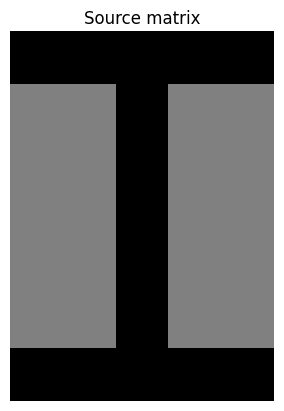

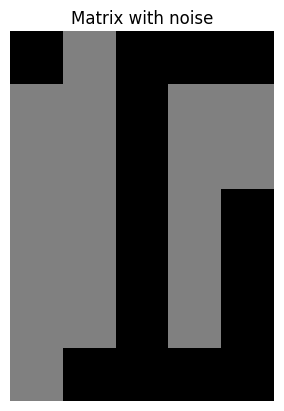

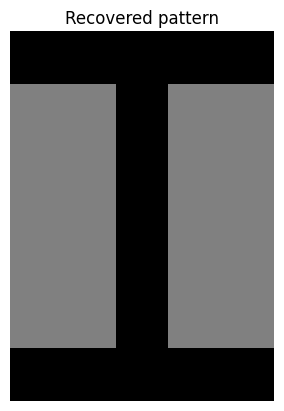

In [61]:
# -----------------------------
# FASE DE RECUPERACIÓN
# -----------------------------
def add_noise_fixed(mx, flips=5):
    matrix = np.array(mx)
    flat = matrix.flatten()
    idx = np.random.choice(len(flat), flips, replace=False)
    flat[idx] *= -1
    return flat.reshape(matrix.shape)

# Entrada
input_matrix = np.array(container_I)
plot_matrix(input_matrix, "Source matrix")
v_input: np.array = add_noise_fixed(input_matrix, flips=5) 
plot_matrix(v_input, "Matrix with noise")


# Desdoblar y convertir la matriz de entrada como un vector columna de tamaño [(n*m) x 1]
column_input_mx = np.array(v_input).reshape(-1, 1, order='F')

# Representa "x(t + 1)" y se inicializa con ceros tamaño [(n*m) x 1]
xt_1 = np.zeros((n*m, 1)) 

# Incializamos "x(0)" con la entrada [(n*m) x 1]
# Esto representará  "x(t)"
xt = column_input_mx

# -----------------------------
#  CICLO DE RECUPERACIÓN
# -----------------------------

def satlins(x: int) -> int:
    if x < 0:
        return -1
    return  1

# Mientras "x(t + 1)" no sea igual a x(t), el ciclo continuará
while not np.array_equal(xt_1, xt):

    # Guardamos en "temp", la multiplicación de la Memoria * x(t)
    temp = sum_matrix @ xt 

    # Se calcula para todo los elementos la función de transferencia
    # -----------------------------
    #  f: satlins(Mij * xij(t)), donde j = 0 y  0 <= i < nxm 
    # -----------------------------
    for i in range(n*m):
        xt_1[i, 0] = satlins(temp[i, 0])

    # x(t) = x(t + 1)
    xt = xt_1.copy()

# Mostramos resultados
plot_matrix(np.array(xt.reshape((7, 5), order='F')), "Recovered pattern")